# Fetch Calendar Features — Festivos Chinos + Temporales

Genera features de calendario para los **8640 timesteps** del dataset ST-EVCDP (19 Jun – 18 Jul 2022, intervalo 5 min).  
Sin API externa — usa la librería `chinese-calendar` (base de datos de festivos oficiales China).

| Feature | Descripción | Uso en prompt |
|---|---|---|
| `is_holiday` | Festivo oficial chino (0/1) | `"Holiday: Yes (Dragon Boat Festival)"` |
| `holiday_name` | Nombre del festivo | idem |
| `is_weekend` | Sábado o domingo (0/1) | `"Day type: Weekend"` |
| `day_of_week` | 0=Lun … 6=Dom | — |
| `hour` | 0–23 | — |
| `hour_sin` / `hour_cos` | Codificación cíclica de la hora | Features numéricas para el modelo |
| `day_sin` / `day_cos` | Codificación cíclica del día de la semana | idem |
| `is_peak_hour` | Hora punta eléctrica Shenzhen (1=pico) | `"Peak electricity hour: Yes"` |
| `time_period` | `morning/afternoon/evening/night` | Descripción natural en prompt |

**Festivos en el período Jun 19 – Jul 18 2022:**
- Dragon Boat Festival: 3 Jun 2022 (justo antes del dataset — pero el efecto de vuelta al trabajo se nota)
- No hay festivos nacionales en Jun 19 – Jul 18 (verificado con `chinese-calendar`)

Output: `calendar_features.csv` (8640 filas)

In [19]:
!pip install chinese-calendar -q

import chinese_calendar as cc
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from pathlib import Path

In [20]:
# ── CONFIGURA AQUÍ tu ruta a los datasets ────────────────────────────
# None = auto-descubrir en Drive (Colab/extensión Colab)
# Si falla, pon la ruta manualmente: "/content/drive/MyDrive/tu_carpeta"
DATASETS_PATH_OVERRIDE = None

import os, glob

if DATASETS_PATH_OVERRIDE:
    DATASETS_PATH = DATASETS_PATH_OVERRIDE
    print(f"Usando ruta manual: {DATASETS_PATH}")
else:
    candidates = glob.glob("/content/drive/**/*information.csv", recursive=True)
    if candidates:
        DATASETS_PATH = os.path.dirname(candidates[0])
        print(f"Encontrado automáticamente: {DATASETS_PATH}")
    else:
        # Intentar montar Drive si no está montado
        try:
            from google.colab import drive
            if not os.path.isdir("/content/drive/MyDrive"):
                drive.mount("/content/drive")
            candidates = glob.glob("/content/drive/**/*information.csv", recursive=True)
            if candidates:
                DATASETS_PATH = os.path.dirname(candidates[0])
                print(f"Encontrado tras montar Drive: {DATASETS_PATH}")
            else:
                print("ERROR: information.csv no encontrado en Drive.")
                print("Pon la ruta correcta en DATASETS_PATH_OVERRIDE arriba.")
                DATASETS_PATH = None
        except ImportError:
            print("No estás en Colab. Pon la ruta en DATASETS_PATH_OVERRIDE.")
            DATASETS_PATH = None

if DATASETS_PATH:
    test_file = f"{DATASETS_PATH}/information.csv"
    if os.path.exists(test_file):
        csvs = glob.glob(f"{DATASETS_PATH}/*.csv")
        print(f"OK — {len(csvs)} CSVs encontrados:")
        for c in sorted(csvs):
            print(f"  {os.path.basename(c)}")
    else:
        print(f"AVISO: information.csv no encontrado en {DATASETS_PATH}")

Encontrado automáticamente: /content/drive/MyDrive/datasets
OK — 10 CSVs encontrados:
  addresses_shenzhen.csv
  adj.csv
  distance.csv
  duration.csv
  information.csv
  occupancy.csv
  price.csv
  stations.csv
  time.csv
  volume.csv


In [21]:
# ── Parámetros ─────────────────────────────────────────────────────────────
START_DT   = "2022-06-19 00:00:00"
FREQ       = "5min"
N_STEPS    = 8640   # 30 días × 288 pasos/día
OUTPUT_PATH = "calendar_features.csv"

# Horas punta eléctricas Shenzhen (Guangdong grid, tarifa industrial/comercial)
# Fuente: SZPG time-of-use tariff (peak: 8-12h, 19-23h workdays)
PEAK_HOURS = set(range(8, 12)) | set(range(19, 23))

# Generar timestamps
timestamps = pd.date_range(start=START_DT, periods=N_STEPS, freq=FREQ)
print(f"Timestamps: {N_STEPS} pasos")
print(f"  Inicio: {timestamps[0]}")
print(f"  Fin:    {timestamps[-1]}")

Timestamps: 8640 pasos
  Inicio: 2022-06-19 00:00:00
  Fin:    2022-07-18 23:55:00


In [22]:
# ── Construir features para cada timestep ─────────────────────────────────
records = []

for ts in timestamps:
    date     = ts.date()
    hour     = ts.hour
    dow      = ts.dayofweek   # 0=Mon … 6=Sun
    minute   = ts.minute

    # Festivo chino oficial (excluye fines de semana normales)
    try:
        hol_detail = cc.get_holiday_detail(date)
        # get_holiday_detail: (is_holiday, name) donde name es None si no es festivo oficial
        # is_holiday=True también para fines de semana → filtramos por nombre
        hol_name   = hol_detail[1] if (hol_detail and hol_detail[1]) else ""
        is_hol     = bool(hol_name)  # Solo True si tiene nombre (festivo oficial)
    except Exception:
        is_hol   = False
        hol_name = ""

    is_weekend = int(dow >= 5)
    is_holiday = int(is_hol)  # Solo festivos oficiales con nombre

    # Hora punta eléctrica (solo días laborables no festivos)
    is_peak = int(hour in PEAK_HOURS and not is_hol and dow < 5)

    # Codificación cíclica (evita discontinuidad hora 23→0, día 6→0)
    hour_total = hour + minute / 60.0   # fracción de hora
    hour_sin   = math.sin(2 * math.pi * hour_total / 24)
    hour_cos   = math.cos(2 * math.pi * hour_total / 24)
    day_sin    = math.sin(2 * math.pi * dow / 7)
    day_cos    = math.cos(2 * math.pi * dow / 7)

    # Período del día (lenguaje natural para prompts)
    if 6 <= hour < 12:
        period = "morning"
    elif 12 <= hour < 18:
        period = "afternoon"
    elif 18 <= hour < 22:
        period = "evening"
    else:
        period = "night"

    # Nombre del día
    day_names = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    day_name  = day_names[dow]

    records.append({
        "timestamp":    ts,
        "day_of_week":  dow,
        "day_name":     day_name,
        "hour":         hour,
        "time_period":  period,
        "is_weekend":   is_weekend,
        "is_holiday":   is_holiday,
        "holiday_name": hol_name,
        "is_peak_hour": is_peak,
        "hour_sin":     round(hour_sin, 6),
        "hour_cos":     round(hour_cos, 6),
        "day_sin":      round(day_sin, 6),
        "day_cos":      round(day_cos, 6),
    })

df_cal = pd.DataFrame(records)

print(f"Shape: {df_cal.shape}")
print(f"\nFestivos encontrados:")
holidays_found = df_cal[df_cal["is_holiday"] == 1][["timestamp", "holiday_name"]].drop_duplicates("holiday_name")
if len(holidays_found):
    print(holidays_found.to_string())
else:
    print("  Ninguno en Jun 19 – Jul 18 2022 (confirmado)")

print(f"\nDistribución day_of_week:")
print(df_cal.groupby("day_name")["timestamp"].count().rename("steps").to_string())

Shape: (8640, 13)

Festivos encontrados:
  Ninguno en Jun 19 – Jul 18 2022 (confirmado)

Distribución day_of_week:
day_name
Friday       1152
Monday       1440
Saturday     1152
Sunday       1440
Thursday     1152
Tuesday      1152
Wednesday    1152


Preview guardado: calendar_features_preview.png


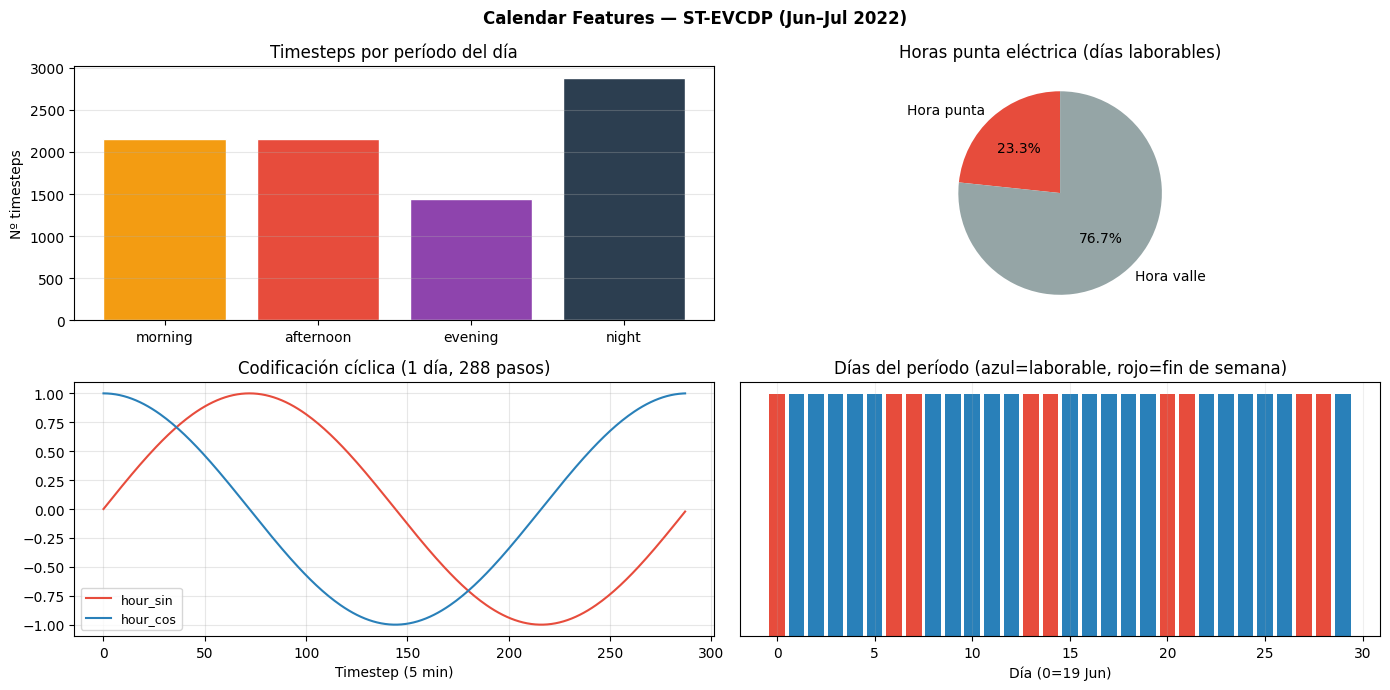

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle("Calendar Features — ST-EVCDP (Jun–Jul 2022)", fontsize=12, fontweight="bold")

# 1. Distribución de períodos del día
period_counts = df_cal["time_period"].value_counts()
period_order  = ["morning", "afternoon", "evening", "night"]
period_colors = ["#F39C12", "#E74C3C", "#8E44AD", "#2C3E50"]
axes[0,0].bar(period_order,
              [period_counts.get(p, 0) for p in period_order],
              color=period_colors, edgecolor="white")
axes[0,0].set_title("Timesteps por período del día")
axes[0,0].set_ylabel("Nº timesteps")
axes[0,0].grid(axis="y", alpha=0.3)

# 2. Horas punta vs valle
peak_counts = df_cal["is_peak_hour"].value_counts()
axes[0,1].pie([peak_counts.get(1,0), peak_counts.get(0,0)],
              labels=["Hora punta", "Hora valle"],
              colors=["#E74C3C", "#95A5A6"],
              autopct="%1.1f%%", startangle=90)
axes[0,1].set_title("Horas punta eléctrica (días laborables)")

# 3. Codificación cíclica de la hora
sample = df_cal[:288]   # 1 día
axes[1,0].plot(sample["hour_sin"].values, color="#E74C3C", lw=1.5, label="hour_sin")
axes[1,0].plot(sample["hour_cos"].values, color="#2980B9", lw=1.5, label="hour_cos")
axes[1,0].set_title("Codificación cíclica (1 día, 288 pasos)")
axes[1,0].set_xlabel("Timestep (5 min)")
axes[1,0].legend(fontsize=9)
axes[1,0].grid(alpha=0.3)

# 4. Weekend/Weekday por día del período
daily = df_cal.groupby(df_cal["timestamp"].dt.date)["is_weekend"].first().reset_index()
colors_day = ["#E74C3C" if w else "#2980B9" for w in daily["is_weekend"]]
axes[1,1].bar(range(len(daily)), [1]*len(daily), color=colors_day, edgecolor="none")
axes[1,1].set_title("Días del período (azul=laborable, rojo=fin de semana)")
axes[1,1].set_xlabel("Día (0=19 Jun)")
axes[1,1].set_yticks([])
axes[1,1].grid(axis="x", alpha=0.2)

plt.tight_layout()
plt.savefig("calendar_features_preview.png", dpi=130, bbox_inches="tight")
print("Preview guardado: calendar_features_preview.png")
plt.show()

In [24]:
df_cal.to_csv(OUTPUT_PATH, index=False)
print(f"Guardado: {OUTPUT_PATH}")
print(f"Shape:    {df_cal.shape}")
print(f"Columnas: {list(df_cal.columns)}")
print(f"\nMuestra (3 filas):")
print(df_cal.head(3).to_string())

# Copiar a Drive si Colab y DATASETS_PATH disponible
try:
    import shutil, os
    if 'DATASETS_PATH' in dir() and DATASETS_PATH and os.path.isdir(DATASETS_PATH):
        dst = f"{DATASETS_PATH}/calendar_features.csv"
        shutil.copy(OUTPUT_PATH, dst)
        print(f"\nCopiado a Drive: {dst}")
    else:
        print("\nDATASETS_PATH no disponible — CSV guardado solo localmente.")
except Exception as e:
    print(f"\nNo se pudo copiar: {e}")

Guardado: calendar_features.csv
Shape:    (8640, 13)
Columnas: ['timestamp', 'day_of_week', 'day_name', 'hour', 'time_period', 'is_weekend', 'is_holiday', 'holiday_name', 'is_peak_hour', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos']

Muestra (3 filas):
            timestamp  day_of_week day_name  hour time_period  is_weekend  is_holiday holiday_name  is_peak_hour  hour_sin  hour_cos   day_sin  day_cos
0 2022-06-19 00:00:00            6   Sunday     0       night           1           0                          0  0.000000  1.000000 -0.781831  0.62349
1 2022-06-19 00:05:00            6   Sunday     0       night           1           0                          0  0.021815  0.999762 -0.781831  0.62349
2 2022-06-19 00:10:00            6   Sunday     0       night           1           0                          0  0.043619  0.999048 -0.781831  0.62349

Copiado a Drive: /content/drive/MyDrive/datasets/calendar_features.csv


In [25]:
import shutil, glob
# Encontrar DATASETS_PATH
candidates = glob.glob("/content/drive/**/*information.csv", recursive=True)
if candidates:
    dst = __import__('os').path.dirname(candidates[0]) + "/calendar_features.csv"
    shutil.copy("/content/calendar_features.csv", dst)
    print("Copiado a:", dst)
else:
    print("Drive no montado o no encontrado")


Copiado a: /content/drive/MyDrive/datasets/calendar_features.csv
